<a href="https://colab.research.google.com/github/iddadobroc/DSML_Group11_Clustering/blob/main/DSML_Group11LA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reach for Change

Part 1: Uncovering Donor Profiles Through Clustering
Data Science and Machine Learning Group Project 2025/2026

| Student #    | Name |
| :-------- | :------- |
| aaa  | 111    |
| bbb |   222   |
| ccc    | 333    |
| 20251105 | Kehinde Adewusi |


In [1]:
import pandas as pd


In [2]:

df = pd.read_csv('https://raw.githubusercontent.com/iddadobroc/DSML_Group11_Clustering/refs/heads/main/donors_descriptive.csv')
df.head()

,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,...,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING
0,61745,4.0,2.000000,33.0,M,0.0,1.0,H,5.0,20.0,...,0.00,17.50,0.0,0.000,2.0,0.154,0.0,2,T,NaN
1,112703,3.0,-2.341107,NaN,F,1.0,1.0,U,NaN,15.0,...,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN
2,166437,4.0,0.000000,74.0,F,7.0,3.0,H,4.0,10.0,...,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN
3,170621,4.0,4.000000,61.0,M,13.0,1.0,H,6.0,11.0,...,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN
4,44428,6.0,3.000000,75.0,M,3.0,4.0,H,3.0,7.0,...,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13560 entries, 0 to 13559
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CONTROL_NUMBER               13560 non-null  int64  
 1   CARD_PROM_12                 13297 non-null  float64
 2   CHILDREN                     13289 non-null  float64
 3   DONOR_AGE                    9970 non-null   float64
 4   DONOR_GENDER                 13303 non-null  object 
 5   FILE_CARD_GIFT               13292 non-null  float64
 6   FREQUENCY_STATUS_97NK        13296 non-null  float64
 7   HOME_OWNER                   13292 non-null  object 
 8   INCOME_GROUP                 10273 non-null  float64
 9   LAST_GIFT_AMT                13296 non-null  float64
 10  LIFETIME_CARD_PROM           13289 non-null  float64
 11  LIFETIME_GIFT_AMOUNT         13288 non-null  float64
 12  LIFETIME_GIFT_COUNT          13304 non-null  float64
 13  LIFETIME_MAX_GIF

In [4]:
df.shape

(13560, 40)

In [5]:
df.isna().sum()

CONTROL_NUMBER                    0
CARD_PROM_12                    263
CHILDREN                        271
DONOR_AGE                      3590
DONOR_GENDER                    257
FILE_CARD_GIFT                  268
FREQUENCY_STATUS_97NK           264
HOME_OWNER                      268
INCOME_GROUP                   3287
LAST_GIFT_AMT                   264
LIFETIME_CARD_PROM              271
LIFETIME_GIFT_AMOUNT            272
LIFETIME_GIFT_COUNT             256
LIFETIME_MAX_GIFT_AMT           276
LIFETIME_MIN_GIFT_AMT           263
LIFETIME_PROM                   274
MEDIAN_HOME_VALUE               255
MEDIAN_HOUSEHOLD_INCOME         251
MONTHS_SINCE_FIRST_GIFT         278
MONTHS_SINCE_LAST_GIFT          275
MONTHS_SINCE_LAST_PROM_RESP     430
NUMBER_PROM_12                  272
PCT_ATTRIBUTE1                  276
PCT_ATTRIBUTE2                  256
PCT_ATTRIBUTE3                  282
PCT_ATTRIBUTE4                  267
PCT_OWNER_OCCUPIED              263
PEP_STAR                    

In [6]:
df

,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,...,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING
0,61745,4.0,2.000000,33.0,M,0.0,1.0,H,5.0,20.0,...,0.00,17.50,0.0,0.000,2.0,0.154,0.0,2,T,NaN
1,112703,3.0,-2.341107,NaN,F,1.0,1.0,U,NaN,15.0,...,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN
2,166437,4.0,0.000000,74.0,F,7.0,3.0,H,4.0,10.0,...,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN
3,170621,4.0,4.000000,61.0,M,13.0,1.0,H,6.0,11.0,...,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN
4,44428,6.0,3.000000,75.0,M,3.0,4.0,H,3.0,7.0,...,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13555,34797,5.0,0.000000,84.0,M,6.0,1.0,H,6.0,10.0,...,10.00,10.00,1.0,0.100,2.0,NaN,6.0,2,C,3.0
13556,7550,7.0,1.000000,86.0,F,16.0,3.0,H,2.0,10.0,...,10.00,7.50,2.0,0.222,4.0,0.211,1.0,2,U,3.0
13557,115215,6.0,2.000000,NaN,M,2.0,3.0,U,1.0,10.0,...,8.50,9.00,2.0,0.250,NaN,0.235,0.0,2,T,NaN
13558,88067,6.0,1.000000,NaN,M,2.0,2.0,U,NaN,15.0,...,10.00,10.00,2.0,0.500,2.0,0.286,0.0,1,S,NaN


In [7]:
df1=df.copy()

In [8]:
df2=df.copy()
df2.drop(columns=["WEALTH_RATING"], inplace = True)

In [9]:
df1

,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,...,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING
0,61745,4.0,2.000000,33.0,M,0.0,1.0,H,5.0,20.0,...,0.00,17.50,0.0,0.000,2.0,0.154,0.0,2,T,NaN
1,112703,3.0,-2.341107,NaN,F,1.0,1.0,U,NaN,15.0,...,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN
2,166437,4.0,0.000000,74.0,F,7.0,3.0,H,4.0,10.0,...,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN
3,170621,4.0,4.000000,61.0,M,13.0,1.0,H,6.0,11.0,...,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN
4,44428,6.0,3.000000,75.0,M,3.0,4.0,H,3.0,7.0,...,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13555,34797,5.0,0.000000,84.0,M,6.0,1.0,H,6.0,10.0,...,10.00,10.00,1.0,0.100,2.0,NaN,6.0,2,C,3.0
13556,7550,7.0,1.000000,86.0,F,16.0,3.0,H,2.0,10.0,...,10.00,7.50,2.0,0.222,4.0,0.211,1.0,2,U,3.0
13557,115215,6.0,2.000000,NaN,M,2.0,3.0,U,1.0,10.0,...,8.50,9.00,2.0,0.250,NaN,0.235,0.0,2,T,NaN
13558,88067,6.0,1.000000,NaN,M,2.0,2.0,U,NaN,15.0,...,10.00,10.00,2.0,0.500,2.0,0.286,0.0,1,S,NaN


In [10]:
df2['CONTROL_NUMBER'].duplicated().sum()

np.int64(0)

In [11]:
df1.set_index("CONTROL_NUMBER", inplace = True)

In [12]:
df1

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,...,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,
61745,4.0,2.000000,33.0,M,0.0,1.0,H,5.0,20.0,9.0,...,0.00,17.50,0.0,0.000,2.0,0.154,0.0,2,T,NaN
112703,3.0,-2.341107,NaN,F,1.0,1.0,U,NaN,15.0,6.0,...,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN
166437,4.0,0.000000,74.0,F,7.0,3.0,H,4.0,10.0,17.0,...,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN
170621,4.0,4.000000,61.0,M,13.0,1.0,H,6.0,11.0,28.0,...,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN
44428,6.0,3.000000,75.0,M,3.0,4.0,H,3.0,7.0,9.0,...,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34797,5.0,0.000000,84.0,M,6.0,1.0,H,6.0,10.0,32.0,...,10.00,10.00,1.0,0.100,2.0,NaN,6.0,2,C,3.0
7550,7.0,1.000000,86.0,F,16.0,3.0,H,2.0,10.0,33.0,...,10.00,7.50,2.0,0.222,4.0,0.211,1.0,2,U,3.0
115215,6.0,2.000000,NaN,M,2.0,3.0,U,1.0,10.0,12.0,...,8.50,9.00,2.0,0.250,NaN,0.235,0.0,2,T,NaN


SES Values 1 to 5 demographic profiles

In [13]:
df2 = df1.copy()
# check uniques SES before cleaning
print('SES - unique values:', df2['SES'].unique())
print('SES - total "?":', (df2['SES'] == '?').sum())
print('SES - missing (NaN):', df2['SES'].isna().sum())

SES - unique values: ['2' '3' '1' '4' nan '?']
SES - total "?": 292
SES - missing (NaN): 286


Sub "?" for NaN

In [14]:
import numpy as np
df2['SES'] = df2['SES'].replace('?', np.nan)
print('SES - unique values:', df2['SES'].unique())
print('SES - missing (NaN):', df2['SES'].isna().sum())

SES - unique values: ['2' '3' '1' '4' nan]
SES - missing (NaN): 578


URBANICITY - values '?'


In [15]:
print('URBANICITY - unique values:', df2['URBANICITY'].unique())
print('URBANICITY - total "?":', (df2['URBANICITY'] == '?').sum())
print('URBANICITY - missing (NaN):', df2['URBANICITY'].isna().sum())

URBANICITY - unique values: ['T' 'R' 'U' 'C' 'S' nan '?']
URBANICITY - total "?": 295
URBANICITY - missing (NaN): 278


Sub "?" for NaN, same as SES


In [16]:
df2['URBANICITY'] = df2['URBANICITY'].replace('?', np.nan)

print('URBANICITY - unique values:', df2['URBANICITY'].unique())
print('URBANICITY - missing (NaN):', df2['URBANICITY'].isna().sum())

URBANICITY - unique values: ['T' 'R' 'U' 'C' 'S' nan]
URBANICITY - missing (NaN): 573


HOME_OWNER 'U' (Unknown) -> NaN

In [17]:
print('HOME_OWNER unique before:', df2['HOME_OWNER'].unique())
df2['HOME_OWNER'] = df2['HOME_OWNER'].replace('U', np.nan)
print('HOME_OWNER unique after:', df2['HOME_OWNER'].unique())

HOME_OWNER unique before: ['H' 'U' nan]
HOME_OWNER unique after: ['H' nan]


Clamp PEP_STAR to valid binary [0, 1], still to be solved properly remove floats, round isn't working

In [18]:
df2['PEP_STAR'].unique()

array([ 0.        ,  1.        , -0.5298607 ,         nan,  2.00360856])

In [19]:
print('\nPEP_STAR unique before:', sorted(df2['PEP_STAR'].dropna().unique()))
df2['PEP_STAR'] = df2['PEP_STAR'].clip(0, 1).round(0)
print('PEP_STAR unique after:', sorted(df2['PEP_STAR'].dropna().unique()))



PEP_STAR unique before: [np.float64(-0.5298607009385796), np.float64(0.0), np.float64(1.0), np.float64(2.0036085611535746)]
PEP_STAR unique after: [np.float64(0.0), np.float64(1.0)]


Clamp RECENT_STAR_STATUS to valid binary [0, 1]

In [20]:
print('\nRECENT_STAR_STATUS range before: [{:.2f}, {:.2f}]'.format(
    df2['RECENT_STAR_STATUS'].min(), df2['RECENT_STAR_STATUS'].max()))
df2['RECENT_STAR_STATUS'] = df2['RECENT_STAR_STATUS'].clip(0, 1).round()
print('RECENT_STAR_STATUS unique after:', sorted(df2['RECENT_STAR_STATUS'].dropna().unique()))



RECENT_STAR_STATUS range before: [-7.81, 22.00]
RECENT_STAR_STATUS unique after: [np.float64(0.0), np.float64(1.0)]


recent star status maybe still to be refined


In [21]:
df2['RECENT_STAR_STATUS'].unique()

array([ 0.,  1., nan])

Clamp INCOME_GROUP to valid range [1, 7]


In [22]:
df2['INCOME_GROUP'].unique()

array([ 5.        ,         nan,  4.        ,  6.        ,  3.        ,
        2.        ,  9.49079901,  1.        ,  7.        , -1.72899876])

In [23]:
print('\nINCOME_GROUP range before: [{:.2f}, {:.2f}]'.format(
    df2['INCOME_GROUP'].min(), df2['INCOME_GROUP'].max()))
df2['INCOME_GROUP'] = df2['INCOME_GROUP'].clip(1, 7).round()
print('INCOME_GROUP unique after:', sorted(df2['INCOME_GROUP'].dropna().unique()))



INCOME_GROUP range before: [-1.73, 9.49]
INCOME_GROUP unique after: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0)]


Detect all numeric columns that currently have negative values

In [24]:
num_cols_all = df2.select_dtypes(include='number').columns
cols_with_negatives = np.array([c for c in num_cols_all if (df2[c] < 0).sum() > 0])


In [25]:
print('Colunas com valores negativos:')
print(cols_with_negatives)
print()
for c in cols_with_negatives:
    print(f'  {c}: {(df2[c] < 0).sum()} negatives  (min={df2[c].min():.3f})')

Colunas com valores negativos:
['CHILDREN' 'FILE_CARD_GIFT' 'FREQUENCY_STATUS_97NK' 'LAST_GIFT_AMT'
 'LIFETIME_CARD_PROM' 'LIFETIME_GIFT_AMOUNT' 'LIFETIME_GIFT_COUNT'
 'LIFETIME_MAX_GIFT_AMT' 'LIFETIME_MIN_GIFT_AMT' 'LIFETIME_PROM'
 'MEDIAN_HOME_VALUE' 'MEDIAN_HOUSEHOLD_INCOME' 'MONTHS_SINCE_FIRST_GIFT'
 'MONTHS_SINCE_LAST_PROM_RESP' 'NUMBER_PROM_12' 'PCT_ATTRIBUTE1'
 'PCT_ATTRIBUTE2' 'PCT_ATTRIBUTE3' 'PCT_ATTRIBUTE4' 'PER_CAPITA_INCOME'
 'RECENT_AVG_CARD_GIFT_AMT' 'RECENT_AVG_GIFT_AMT'
 'RECENT_CARD_RESPONSE_COUNT' 'RECENT_CARD_RESPONSE_PROP'
 'RECENT_RESPONSE_COUNT' 'RECENT_RESPONSE_PROP' 'WEALTH_RATING']

  CHILDREN: 75 negatives  (min=-2.341)
  FILE_CARD_GIFT: 64 negatives  (min=-10.100)
  FREQUENCY_STATUS_97NK: 70 negatives  (min=-1.365)
  LAST_GIFT_AMT: 70 negatives  (min=-21.719)
  LIFETIME_CARD_PROM: 68 negatives  (min=-7.189)
  LIFETIME_GIFT_AMOUNT: 66 negatives  (min=-245.473)
  LIFETIME_GIFT_COUNT: 70 negatives  (min=-18.583)
  LIFETIME_MAX_GIFT_AMT: 67 negatives  (min=-33.4

Clip to 0 on columns that cannot be negative

In [26]:
non_negative_cols = [
    'CHILDREN', 'FILE_CARD_GIFT', 'FREQUENCY_STATUS_97NK',
    'LAST_GIFT_AMT', 'LIFETIME_CARD_PROM', 'LIFETIME_GIFT_AMOUNT',
    'LIFETIME_GIFT_COUNT', 'LIFETIME_MAX_GIFT_AMT', 'LIFETIME_MIN_GIFT_AMT',
    'LIFETIME_PROM', 'MEDIAN_HOME_VALUE', 'MEDIAN_HOUSEHOLD_INCOME',
    'MONTHS_SINCE_FIRST_GIFT', 'MONTHS_SINCE_LAST_PROM_RESP',
    'NUMBER_PROM_12', 'PCT_ATTRIBUTE1', 'PCT_ATTRIBUTE2', 'PCT_ATTRIBUTE3',
    'PCT_ATTRIBUTE4', 'PCT_OWNER_OCCUPIED', 'PER_CAPITA_INCOME',
    'RECENT_AVG_CARD_GIFT_AMT', 'RECENT_AVG_GIFT_AMT',
    'RECENT_CARD_RESPONSE_COUNT', 'RECENT_CARD_RESPONSE_PROP',
    'RECENT_RESPONSE_COUNT', 'RECENT_RESPONSE_PROP', 'MONTHS_SINCE_LAST_GIFT',
    'CARD_PROM_12'
]

for col in non_negative_cols:
    if col in df2.columns:
        df2[col] = df2[col].clip(lower=0)

# Verify no negatives remain
remaining = {c: (df2[c] < 0).sum() for c in df2.select_dtypes(include='number').columns if (df2[c] < 0).sum() > 0}
print('Negatives :', remaining if remaining else "")

Negatives : {'WEALTH_RATING': np.int64(67)}



Missing values??

In [27]:
missing = df2.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Columns with missing values:')
print(missing.to_string())


Columns with missing values:
HOME_OWNER                     6309
WEALTH_RATING                  6269
DONOR_AGE                      3590
INCOME_GROUP                   3287
SES                             578
URBANICITY                      573
MONTHS_SINCE_LAST_PROM_RESP     430
PCT_ATTRIBUTE3                  282
MONTHS_SINCE_FIRST_GIFT         278
RECENT_CARD_RESPONSE_COUNT      278
PCT_ATTRIBUTE1                  276
LIFETIME_MAX_GIFT_AMT           276
MONTHS_SINCE_LAST_GIFT          275
RECENT_STAR_STATUS              275
RECENT_CARD_RESPONSE_PROP       274
LIFETIME_PROM                   274
NUMBER_PROM_12                  272
LIFETIME_GIFT_AMOUNT            272
CHILDREN                        271
LIFETIME_CARD_PROM              271
FILE_CARD_GIFT                  268
RECENT_AVG_GIFT_AMT             268
PCT_ATTRIBUTE4                  267
RECENT_RESPONSE_COUNT           266
RECENCY_STATUS_96NK             266
PEP_STAR                        265
FREQUENCY_STATUS_97NK           264

Columns DONOR_GENDER, HOME_OWNER, RECENCY_STATUS_96NK, SES, URBANICITY.
We impute with the mode (most frequent value) for each.

In [28]:
cat_cols = ['DONOR_GENDER', 'HOME_OWNER', 'RECENCY_STATUS_96NK', 'SES', 'URBANICITY']
for col in cat_cols:
    n_miss = df2[col].isna().sum()
    mode_val = df2[col].mode()[0]
    print(f'{col}: {n_miss} missing | mode = {mode_val!r}')
    print(f'  {dict(df2[col].value_counts(dropna=False))}')
    print()

DONOR_GENDER: 257 missing | mode = 'F'
  {'F': np.int64(7222), 'M': np.int64(5376), 'U': np.int64(705), nan: np.int64(257)}

HOME_OWNER: 6309 missing | mode = 'H'
  {'H': np.int64(7251), nan: np.int64(6309)}

RECENCY_STATUS_96NK: 266 missing | mode = 'A'
  {'A': np.int64(8202), 'S': np.int64(2877), 'F': np.int64(1048), 'N': np.int64(825), 'E': np.int64(283), nan: np.int64(266), 'L': np.int64(59)}

SES: 578 missing | mode = '2'
  {'2': np.int64(6365), '1': np.int64(4091), '3': np.int64(2277), nan: np.int64(578), '4': np.int64(249)}

URBANICITY: 573 missing | mode = 'S'
  {'S': np.int64(3103), 'C': np.int64(2741), 'T': np.int64(2734), 'R': np.int64(2732), 'U': np.int64(1677), nan: np.int64(573)}



In [29]:
cat_cols = ['DONOR_GENDER', 'HOME_OWNER', 'RECENCY_STATUS_96NK', 'SES', 'URBANICITY']
for col in cat_cols:
    mode_val = df2[col].mode()[0]
    df2[col] = df2[col].fillna(mode_val)

print('Missing in categorical columns')
print(df2[cat_cols].isna().sum())

Missing in categorical columns
DONOR_GENDER           0
HOME_OWNER             0
RECENCY_STATUS_96NK    0
SES                    0
URBANICITY             0
dtype: int64


2.4.3 CHILDREN (median + round + clamp [0, 6])

CHILDREN is a count — it must be a non-negative integer. We impute with the median, then round and clamp to [0, 6].

In [30]:
col = 'CHILDREN'
print(f'{col}: {df2[col].isna().sum()} missing ({df2[col].isna().mean()*100:.1f}%)')
print(f'Median: {df2[col].median()}')
print(f'\nValue counts:')
print(df2[col].value_counts(dropna=False).sort_index())

CHILDREN: 271 missing (2.0%)
Median: 2.0

Value counts:
CHILDREN
0.000000    2656
1.000000    2658
2.000000    2631
3.000000    2630
4.000000    2646
6.264709      68
NaN          271
Name: count, dtype: int64


In [31]:
df2['CHILDREN'] = df2['CHILDREN'].fillna(df2['CHILDREN'].median()).round().clip(0, 6)
print('CHILDREN after imputation:')
print(df2['CHILDREN'].value_counts(dropna=False).sort_index())
print(f'Missing: {df2["CHILDREN"].isna().sum()}')

CHILDREN after imputation:
CHILDREN
0.0    2656
1.0    2658
2.0    2902
3.0    2630
4.0    2646
6.0      68
Name: count, dtype: int64
Missing: 0


DONOR_AGE

In [32]:
col = 'DONOR_AGE'
print(f'{col}: {df2[col].isna().sum()} missing ({df2[col].isna().mean()*100:.1f}%)')
print(f'Median: {df2[col].median()} | Mean: {df2[col].mean():.1f}')
print(f'Min: {df2[col].min()} | Max: {df2[col].max()}')

DONOR_AGE: 3590 missing (26.5%)
Median: 60.0 | Mean: 58.9
Min: 0.0 | Max: 108.93426092026507


(median — 26.5% missing)-Age distribution is typically right skewed. Maybe use median

In [33]:
df2['DONOR_AGE'] = df2['DONOR_AGE'].fillna(df2['DONOR_AGE'].median())
print(f'{col}: {df2[col].isna().sum()} missing ({df2[col].isna().mean()*100:.1f}%)')

DONOR_AGE: 0 missing (0.0%)


Income Group

In [34]:
col = 'INCOME_GROUP'
print(f'{col}: {df2[col].isna().sum()} missing ({df2[col].isna().mean()*100:.1f}%)')
print(f'Median: {df2[col].median()}')
print(f'\nValue counts (incl. NaN):')
print(df2[col].value_counts(dropna=False).sort_index())

INCOME_GROUP: 3287 missing (24.2%)
Median: 4.0

Value counts (incl. NaN):
INCOME_GROUP
1.0    1278
2.0    1758
3.0    1133
4.0    1732
5.0    2177
6.0    1076
7.0    1119
NaN    3287
Name: count, dtype: int64


INCOME_GROUP (median — 24.2% missing)
INCOME_GROUP is an ordinal [1–7]. We impute with the median and round to keep valid integer categories.

In [35]:
df2['INCOME_GROUP'] = df2['INCOME_GROUP'].fillna(df2['INCOME_GROUP'].median()).round().clip(1, 7)
print(df2[col].value_counts(dropna=False).sort_index())


INCOME_GROUP
1.0    1278
2.0    1758
3.0    1133
4.0    5019
5.0    2177
6.0    1076
7.0    1119
Name: count, dtype: int64


Check Whats missing
We still have to check for:
  Duplicates on both columns and after pearsons remove the dependant var

In [36]:
print('Duplicated index (CONTROL_NUMBER):', df2.index.duplicated().sum())
print('Duplicated rows (all columns):', df2.duplicated().sum())

Duplicated index (CONTROL_NUMBER): 0
Duplicated rows (all columns): 0


In [37]:
df2 = df2[~df2.index.duplicated(keep='first')]
df2 = df2.drop_duplicates()
print('Shape after duplicate removal:', df2.shape)

Shape after duplicate removal: (13560, 39)


Pearsons Diagram to check on Dependancy

Dataset usado para Pearson: df2
Nº de variáveis no diagrama: 34


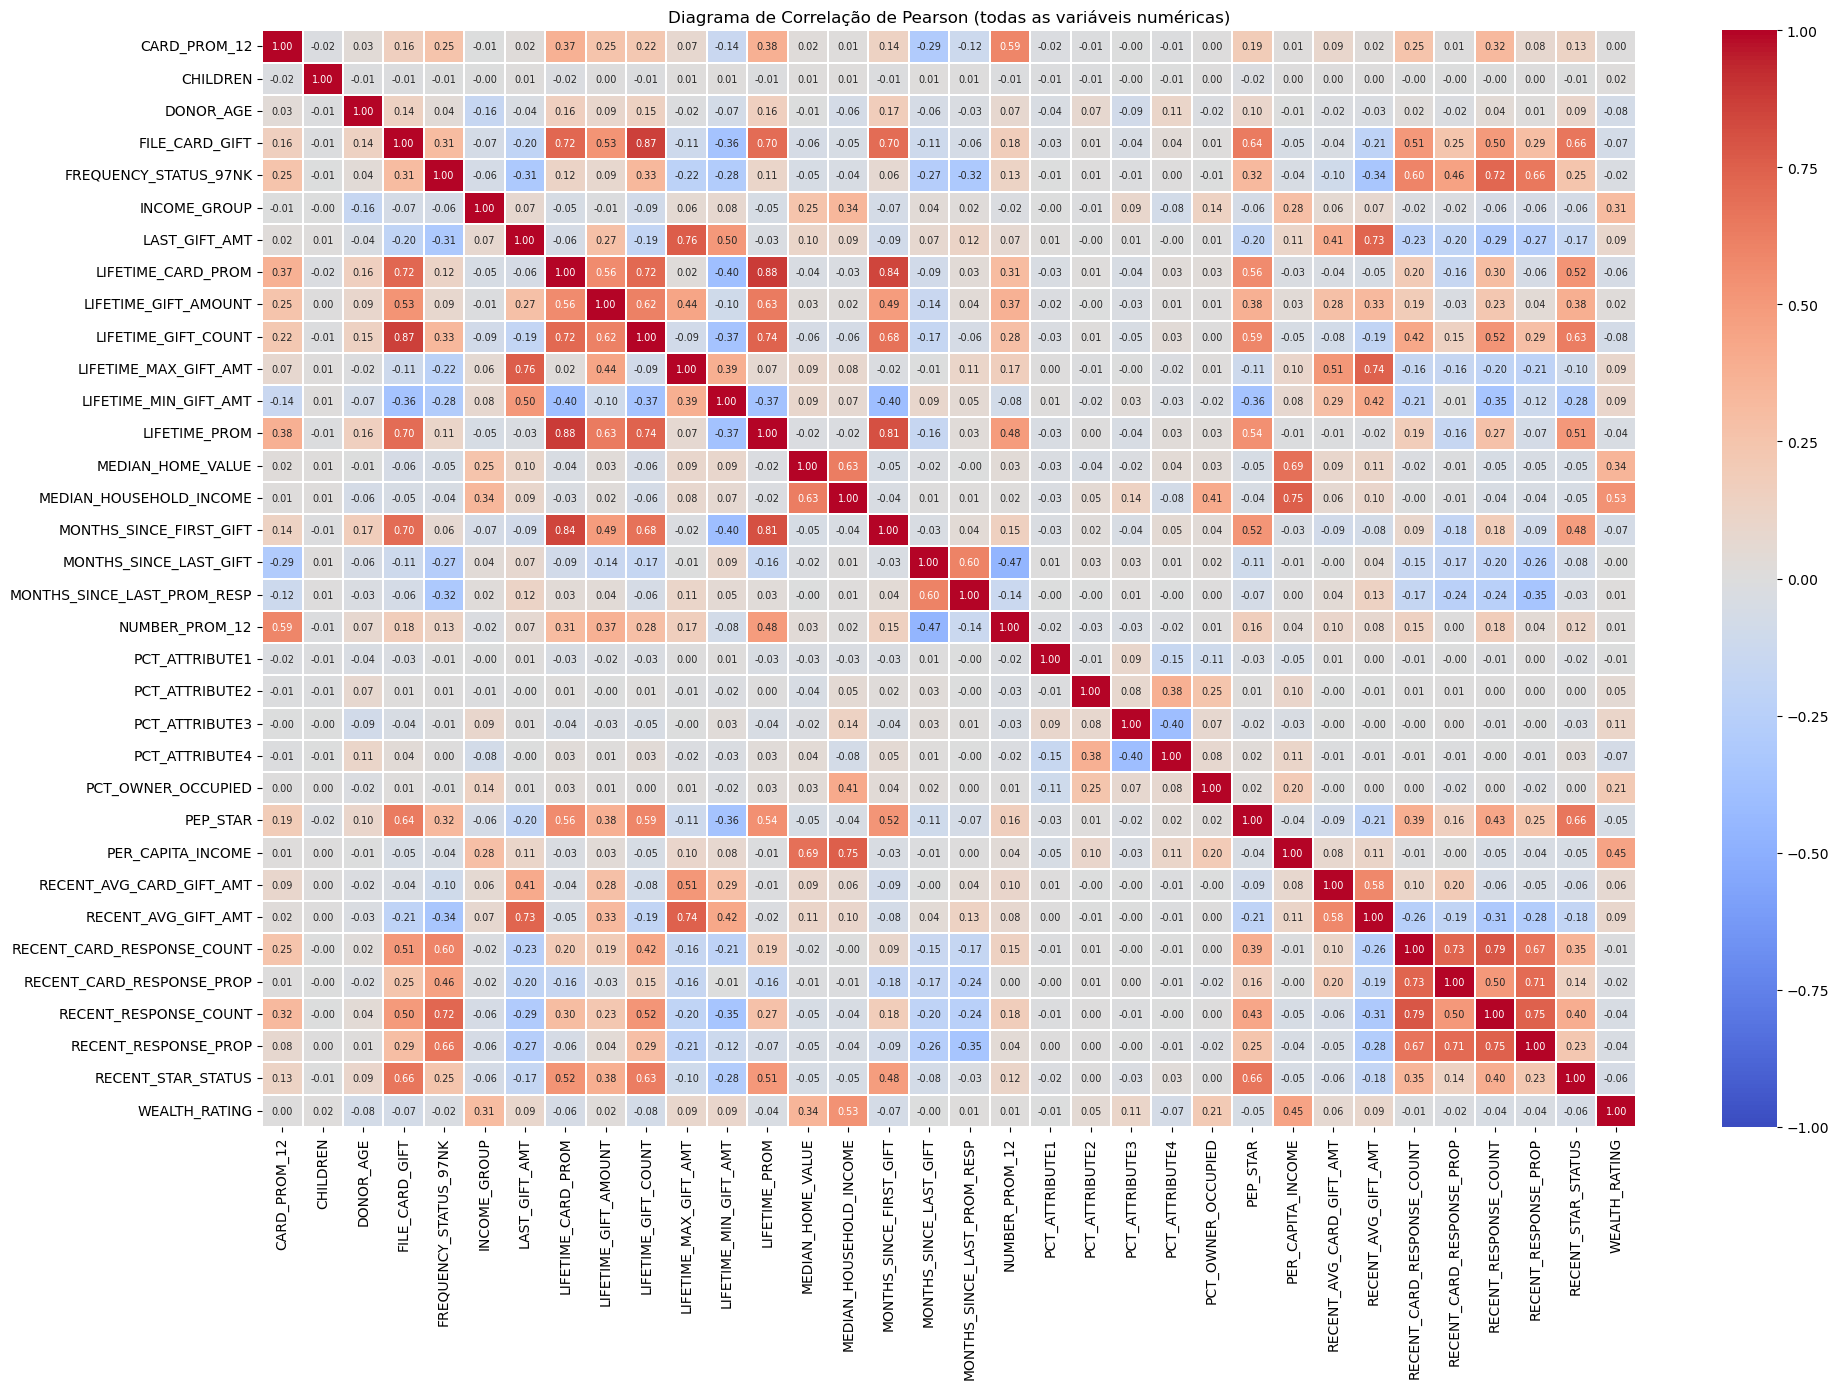

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# usar o dataset mais avançado que existir
if 'df5' in globals():
    df_corr_base = df5.copy()
elif 'df4' in globals():
    df_corr_base = df4.copy()
else:
    df_corr_base = df2.copy()

# Pearson só funciona em colunas numéricas
corr_df = df_corr_base.select_dtypes(include='number')
pearson_corr = corr_df.corr(method='pearson')

print('Dataset usado para Pearson:', 'df5' if 'df5' in globals() else ('df4' if 'df4' in globals() else 'df2'))
print('Nº de variáveis no diagrama:', pearson_corr.shape[0])

plt.figure(figsize=(20, 14))
sns.heatmap(
    pearson_corr,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=False,
    linewidths=0.2,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7}
    )
plt.title('Diagrama de Correlação de Pearson (todas as variáveis numéricas)')
plt.tight_layout()
plt.show()

In [39]:
import numpy as np
import pandas as pd

thr = 0.75

if 'pearson_corr' not in globals():
    corr_df = df5.select_dtypes(include='number') if 'df5' in globals() else df2.select_dtypes(include='number')
    pearson_corr = corr_df.corr(method='pearson')

corr_abs = pearson_corr.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'abs_r'})
)
pairs = pairs[pairs['abs_r'] > thr].sort_values('abs_r', ascending=False).reset_index(drop=True)

# adicionar r com sinal para análise
pairs['r'] = pairs.apply(lambda x: pearson_corr.loc[x['var1'], x['var2']], axis=1)
pairs = pairs[['var1', 'var2', 'r', 'abs_r']]

print(f'Pares com |r| > {thr}: {len(pairs)}')
display(pairs)

# sugestao automatica simples: remover var2 de cada par
if len(pairs) > 0:
    suggested_remove = pairs['var2'].drop_duplicates().tolist()
    print('\nSugestao (automatica): remover uma por par, começando por estas:')
    print(suggested_remove)

Pares com |r| > 0.75: 7


,var1,var2,r,abs_r
0,LIFETIME_CARD_PROM,LIFETIME_PROM,0.880728,0.880728
1,FILE_CARD_GIFT,LIFETIME_GIFT_COUNT,0.866220,0.866220
2,LIFETIME_CARD_PROM,MONTHS_SINCE_FIRST_GIFT,0.843808,0.843808
3,LIFETIME_PROM,MONTHS_SINCE_FIRST_GIFT,0.806433,0.806433
4,RECENT_CARD_RESPONSE_COUNT,RECENT_RESPONSE_COUNT,0.788052,0.788052
5,LAST_GIFT_AMT,LIFETIME_MAX_GIFT_AMT,0.758006,0.758006
6,MEDIAN_HOUSEHOLD_INCOME,PER_CAPITA_INCOME,0.753560,0.753560



Sugestao (automatica): remover uma por par, começando por estas:
['LIFETIME_PROM', 'LIFETIME_GIFT_COUNT', 'MONTHS_SINCE_FIRST_GIFT', 'RECENT_RESPONSE_COUNT', 'LIFETIME_MAX_GIFT_AMT', 'PER_CAPITA_INCOME']


Drop de 'LIFETIME_PROM', 'MONTHS_SINCE_FIRST_GIFT', 'LIFETIME_GIFT_COUNT' since had +83% dependancy of other vars
+RECENT_RESPONSE_COUNT since it has 0.76 dependancy on RECENT_RESPONSE_PROP and they are very similar
+'RECENT_CARD_RESPONSE_COUNT' since it has 0.74 dependancy on RECENT_CARD_RESPONSE_PROP and they are very similar
+RECENT_AVG_CARD_GIFT_AMT since it has 0.74 dependancy on RECENT_CARD_RESPONSE_PROP and they are very similar 'LAST_GIFT_AMT'

Colunas removidas: ['LIFETIME_PROM', 'MONTHS_SINCE_FIRST_GIFT', 'LIFETIME_GIFT_COUNT', 'RECENT_RESPONSE_COUNT', 'RECENT_CARD_RESPONSE_COUNT', 'RECENT_AVG_CARD_GIFT_AMT', 'MEDIAN_HOUSEHOLD_INCOME']
Shape antes: (13560, 39)
Shape depois: (13560, 32)


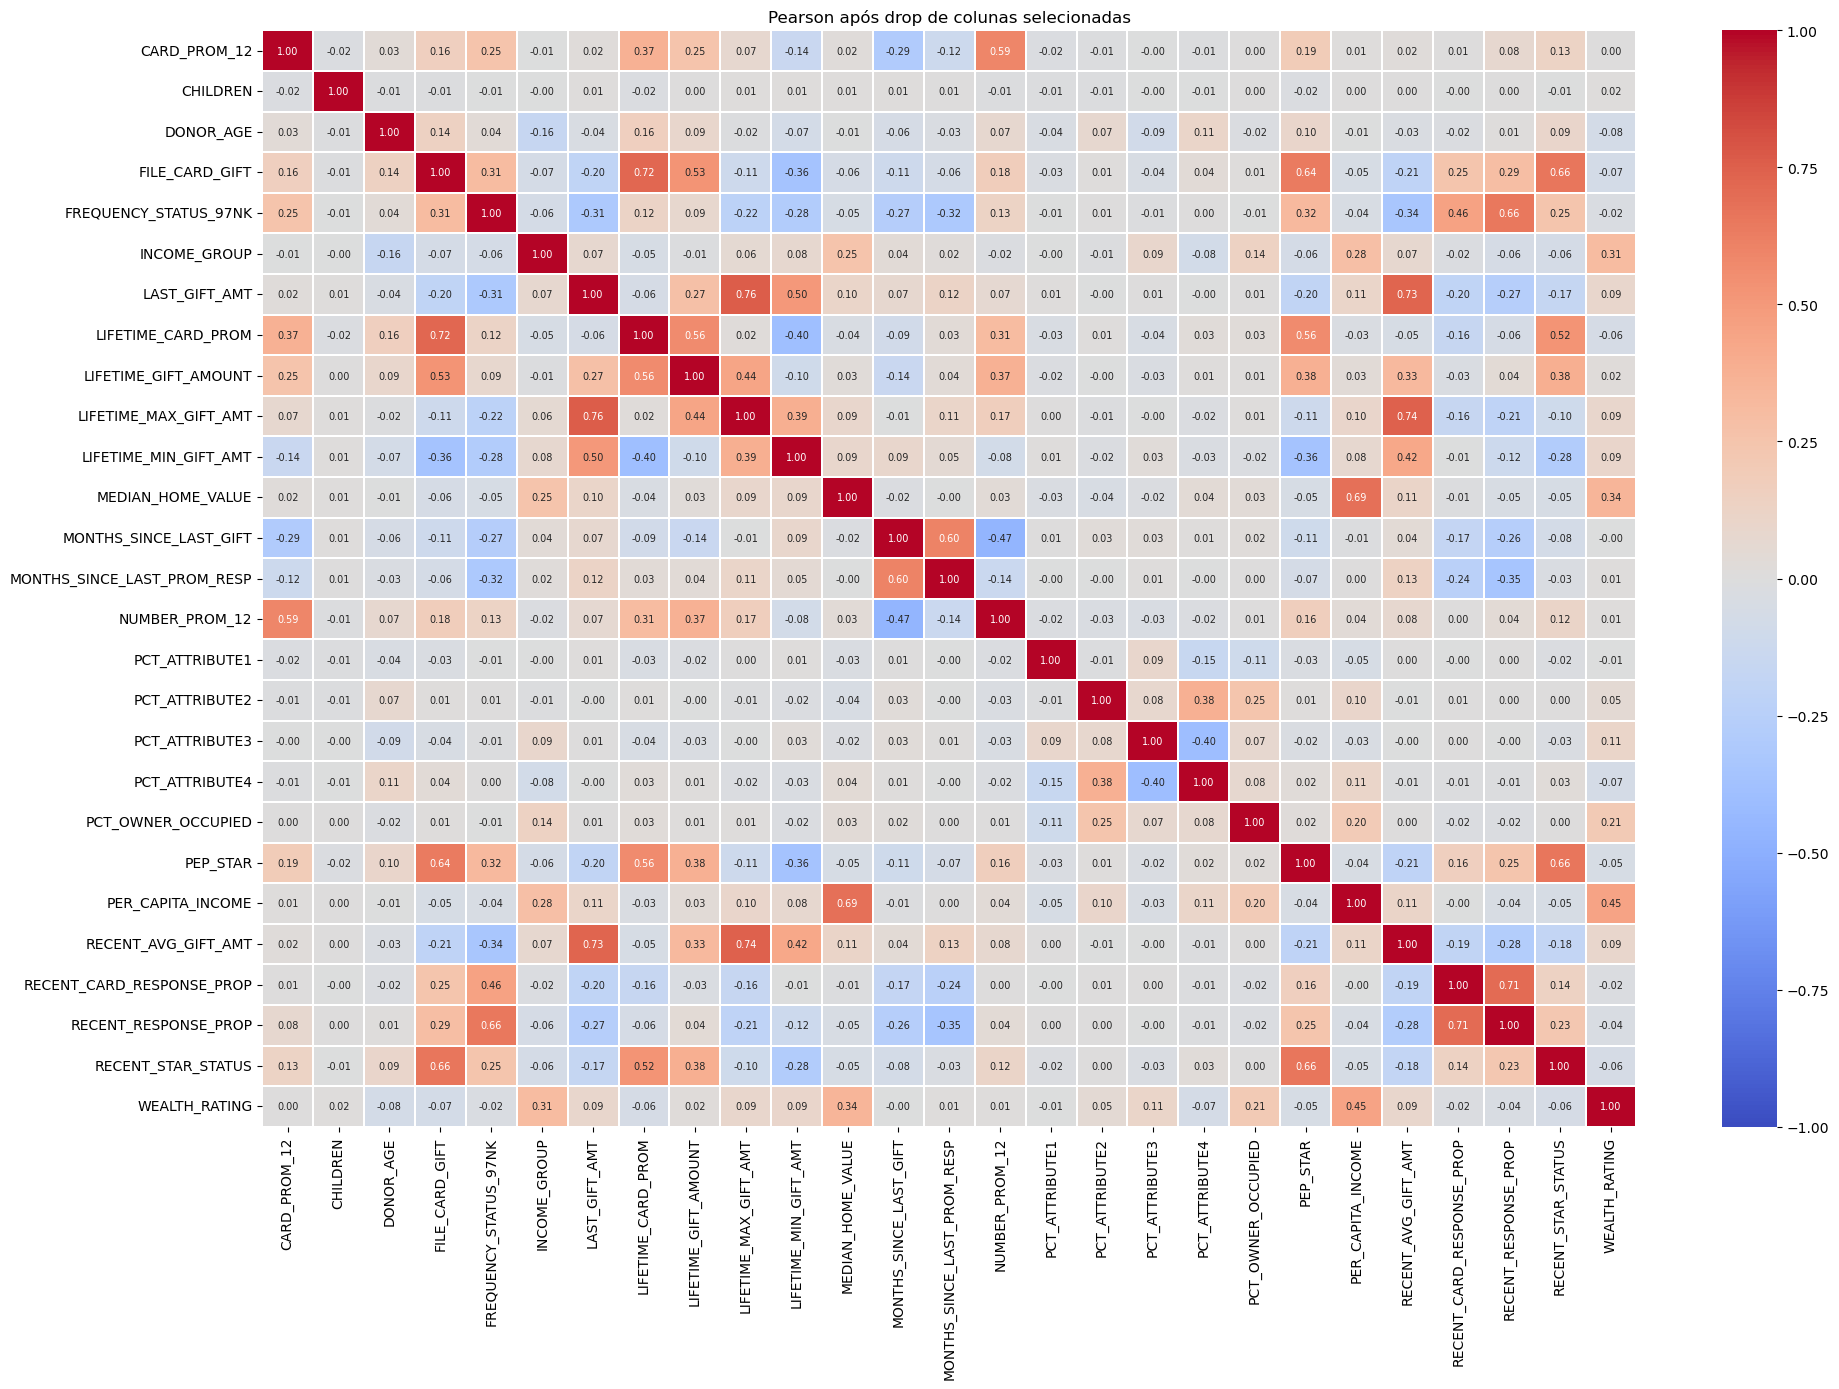

In [40]:
# Drop das variáveis escolhidas e novo Pearson
drop_cols = ['LIFETIME_PROM', 'MONTHS_SINCE_FIRST_GIFT', 'LIFETIME_GIFT_COUNT', 'RECENT_RESPONSE_COUNT', 'RECENT_CARD_RESPONSE_COUNT', 'RECENT_AVG_CARD_GIFT_AMT', 'MEDIAN_HOUSEHOLD_INCOME']

# usa df5 se existir; caso contrário usa df2
df_base_drop = df5.copy() if 'df5' in globals() else df2.copy()
df6 = df_base_drop.drop(columns=drop_cols, errors='ignore')

print('Colunas removidas:', [c for c in drop_cols if c in df_base_drop.columns])
print('Shape antes:', df_base_drop.shape)
print('Shape depois:', df6.shape)

# Recalcular Pearson após drop
corr_df = df6.select_dtypes(include='number')
pearson_corr = corr_df.corr(method='pearson')

plt.figure(figsize=(20, 14))
sns.heatmap(
    pearson_corr,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.2,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7}
    )
plt.title('Pearson após drop de colunas selecionadas')
plt.tight_layout()
plt.show()

In [ ]:
df_current = df6.copy()
#Coment to see